In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.feature as cfeature
import datetime as dt
from IPython.display import Markdown as md
import os, re
import datetime as dt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import KFold
from sklearn.model_selection import TimeSeriesSplit

import sys
sys.path.insert(0, '/home/563/dy2988/statistical_enso')
from prediction_analysis_Dine import combo_method_SKL_Dine, brier_skill_score, calculate_classed_leps_skill, leps_skill, get_classification_scores, combo_method_SKL_train_test, combo_method_SKL_validation 


In [2]:
# import and convert MDB mean and total rainfall to panda series
mdb_mean = xr.open_dataset('data/mdb_mean_rainfall.nc')
mdb_total = xr.open_dataset('data/mdb_total_rainfall.nc')

mdb_mean_series = mdb_mean['precip'].to_series()
mdb_total_series = mdb_total['precip'].to_series()

In [3]:
# import and convert hadisst roni and oni to panda series
oni = xr.open_dataset('data/oni_hadisst.nc')
roni = xr.open_dataset('data/roni_hadisst.nc')

oni_series = oni['sst'].to_series() # 3 month rolling average (centered, e.g. JJA - July)
roni_series = roni['sst'].to_series()

In [4]:
roni_series.index.month.values

array([1, 2, 3, ..., 5, 6, 7], dtype=int32)

In [5]:
# Indices values are indexed as centre month. 
# But want to change index as DJF - Feb, so less confusion in calculating/understanding lead time. 
# If JJA: 8, then when predicting SON, it will be 1-month lead forecast (bc August is in between)
# then when AMJ (6) predicts SON, it will be a 3-month lead forecast (6,7,8 is in between)

# extract predictor dataset (oni & roni)  

def shift_index_one_month(data):
    data = data.copy()
    data.index = data.index + pd.DateOffset(months=1)
    return data

oni_data = shift_index_one_month(oni_series)
roni_data = shift_index_one_month(roni_series)
roni_data

time
1870-02-16 11:59:59.505615234         NaN
1870-03-14 23:59:59.340820312   -0.612827
1870-04-16 11:59:59.340820312   -0.505451
1870-05-15 23:59:59.340820312   -0.541640
1870-06-16 12:00:00.000000000   -0.583550
                                   ...   
2026-04-16 12:00:00.000000000   -0.377770
2026-05-16 00:00:00.000000000    0.004068
2026-06-16 12:00:00.000000000    0.485978
2026-07-16 00:00:00.000000000    0.976325
2026-08-16 12:00:00.000000000         NaN
Name: sst, Length: 1879, dtype: float32

In [6]:
# set all data to 1900 onwards (longest available data) 

dt1900 = dt.datetime(1900,2,16)

roni_data = roni_data[dt1900:].copy()
oni_data = oni_data[dt1900:].copy()
mdb_mean_data = mdb_mean_series[dt1900:].copy()
mdb_total_data = mdb_total_series[dt1900:].copy()


In [7]:
mdb_mean_data

time
1900-03-16 00:00:00    63.117325
1900-04-15 12:00:00    40.177437
1900-05-16 00:00:00    50.528648
1900-06-15 12:00:00    51.724636
1900-07-16 00:00:00    43.112389
                         ...    
2025-08-16 00:00:00    31.472557
2025-09-15 12:00:00    29.625412
2025-10-16 00:00:00    22.634979
2025-11-15 12:00:00    36.333515
2025-12-16 00:00:00    36.652603
Name: precip, Length: 1510, dtype: float32

In [8]:
# 1 month lead predictors: 3m mean june july august
roni_jja = roni_data[roni_data.index.month == 9].copy()
oni_jja = oni_data[oni_data.index.month == 9].copy()

# 3 month lead predictors: 3m mean april may june
roni_amj = roni_data[roni_data.index.month == 6].copy()
oni_amj = oni_data[oni_data.index.month == 6].copy()


#############set total rainfall or mean rainfall over MDB###################
# current: mean SON rainfall OVER MDB !!! 
# to see total MDB, change 'mdb_mean_data' to 'mdb_total_data'
mdb_data = mdb_mean_data

tp_son = (
    mdb_data[mdb_data.index.month.isin([9, 10, 11])]
    .groupby(mdb_data[mdb_data.index.month.isin([9, 10, 11])].index.year)
    .sum()
)

mp_son = (
    mdb_data[mdb_data.index.month.isin([9, 10, 11])]
    .groupby(mdb_data[mdb_data.index.month.isin([9, 10, 11])].index.year)
    .mean()
)
        

In [9]:
## Check we have useful data
# hadisst roni oni_jja only available up to 2025 bc 2026 data was up to july (mjj), update now ? 
for df,name in zip([roni_jja,oni_jja,roni_amj,oni_amj,tp_son, mp_son],
                   ['roni_jja','oni_jja','roni_amj','oni_amj','tp','mp']):
    print("===  ",name,"  ===")
    print("  data available from ",df.index[0], " to ", df.index[-1])
    
    print('  last five entries:')
    print(df[-5:])
    print() # breakline

===   roni_jja   ===
  data available from  1900-09-16 12:00:00  to  2025-09-16 12:00:00
  last five entries:
time
2021-09-16 12:00:00   -0.573886
2022-09-16 12:00:00   -0.976900
2023-09-16 12:00:00    1.046599
2024-09-16 12:00:00   -0.458692
2025-09-16 12:00:00   -0.425110
Name: sst, dtype: float32

===   oni_jja   ===
  data available from  1900-09-16 12:00:00  to  2025-09-16 12:00:00
  last five entries:
time
2021-09-16 12:00:00   -0.415976
2022-09-16 12:00:00   -0.911636
2023-09-16 12:00:00    1.422412
2024-09-16 12:00:00   -0.025739
2025-09-16 12:00:00   -0.205636
Name: sst, dtype: float32

===   roni_amj   ===
  data available from  1900-06-16 12:00:00  to  2026-06-16 12:00:00
  last five entries:
time
2022-06-16 12:00:00   -1.176597
2023-06-16 12:00:00    0.136041
2024-06-16 12:00:00   -0.090947
2025-06-16 12:00:00   -0.412333
2026-06-16 12:00:00    0.485978
Name: sst, dtype: float32

===   oni_amj   ===
  data available from  1900-06-16 12:00:00  to  2026-06-16 12:00:00
  last 

In [10]:
# run prediction

PREDICTION_YEAR=2025 # 2025 for jja, 2026 for amj, need to change X1, X2 accordingly below

# outputs for each target will be stored as a list
output_row        = []
# list will have several named entries and be put into a table
output_columns = [
    'P_roni(t1)','P_roni(t2)','P_roni(t3)',
    'P_oni(t1)','P_oni(t2)','P_oni(t3)',
    'rainfall mean','rainfall SD','rainfall median'
    ]

Y=mp_son
proba_roni, proba_oni, q33, q67 = combo_method_SKL_Dine(
        X1=roni_jja,
        X2=oni_jja,
        Y=Y,
        training_years=None,
        prediction_years=[PREDICTION_YEAR],
    )

    ## Mean and std of SON mean rainfall over MBD over 1900-2025 , include 2025 or not?
mean = Y.mean()
std = Y.std()
median = Y.median()
    
## Add row to list
output_row.append([proba_roni[0,0],proba_roni[0,1],proba_roni[0,2],
                   proba_oni[0,0],proba_oni[0,1],proba_oni[0,2],
                   mean,std,median])
    
## Make list of rows into dataframe for easy printing...
df_stats=pd.DataFrame(output_row,columns=output_columns)
pd.set_option('display.float_format', '{:.2f}'.format)

# Check output
print("1-month lead SON prediction for %d"%(PREDICTION_YEAR))
print()
print(df_stats)

1-month lead SON prediction for 2025

   P_roni(t1)  P_roni(t2)  P_roni(t3)  P_oni(t1)  P_oni(t2)  P_oni(t3)  \
0        0.16        0.32        0.52       0.31       0.36       0.33   

   rainfall mean  rainfall SD  rainfall median  
0          38.99        16.73            35.73  


In [11]:
# run prediction

PREDICTION_YEAR=2026 # 2025 for jja, 2026 for amj, need to change X1, X2 accordingly below

# outputs for each target will be stored as a list
output_row        = []
# list will have several named entries and be put into a table
output_columns = [
    'P_roni(t1)','P_roni(t2)','P_roni(t3)',
    'P_oni(t1)','P_oni(t2)','P_oni(t3)',
    'rainfall mean','rainfall SD','rainfall median'
    ]

Y=mp_son
proba_roni, proba_oni, q33, q67 = combo_method_SKL_Dine(
        X1=roni_amj,
        X2=oni_amj,
        Y=Y,
        prediction_years=[PREDICTION_YEAR],
    )

    ## Mean and std of SON mean rainfall over MBD over 1900-2025, include 2025 or not?
mean = Y.mean()
std = Y.std()
median = Y.median()
    
## Add row to list
output_row.append([proba_roni[0,0],proba_roni[0,1],proba_roni[0,2],
                   proba_oni[0,0],proba_oni[0,1],proba_oni[0,2],
                   mean,std,median])
    
## Make list of rows into dataframe for easy printing...
df_stats=pd.DataFrame(output_row,columns=output_columns)
pd.set_option('display.float_format', '{:.2f}'.format)

# Check output
print("3-month lead SON prediction for %d"%(PREDICTION_YEAR))
print()
print(df_stats)

3-month lead SON prediction for 2026

   P_roni(t1)  P_roni(t2)  P_roni(t3)  P_oni(t1)  P_oni(t2)  P_oni(t3)  \
0        0.43        0.30        0.27       0.56       0.25       0.19   

   rainfall mean  rainfall SD  rainfall median  
0          38.99        16.73            35.73  


In [12]:
roni_jja.index

DatetimeIndex(['1900-09-16 12:00:00', '1901-09-16 12:00:00',
               '1902-09-16 12:00:00', '1903-09-16 12:00:00',
               '1904-09-16 12:00:00', '1905-09-16 12:00:00',
               '1906-09-16 12:00:00', '1907-09-16 12:00:00',
               '1908-09-16 12:00:00', '1909-09-16 12:00:00',
               ...
               '2016-09-16 12:00:00', '2017-09-16 12:00:00',
               '2018-09-16 12:00:00', '2019-09-16 12:00:00',
               '2020-09-16 12:00:00', '2021-09-16 12:00:00',
               '2022-09-16 12:00:00', '2023-09-16 12:00:00',
               '2024-09-16 12:00:00', '2025-09-16 12:00:00'],
              dtype='datetime64[ns]', name='time', length=126, freq=None)

In [13]:
mp_son.index

Index([1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909,
       ...
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
      dtype='int32', name='time', length=126)

In [14]:
# Run Out-of-sample validation

[1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963
 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977
 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991
 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005
 2006 2007 2008 2009] [2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023
 2024 2025]


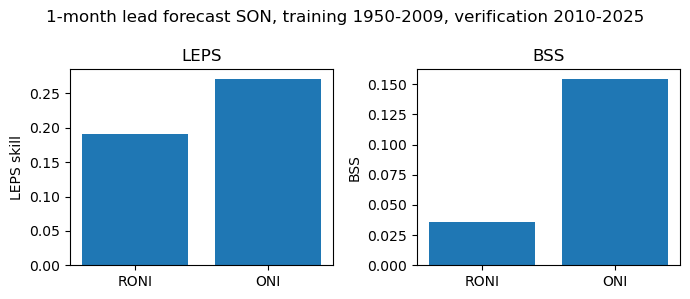

In [15]:
# bom's validaton was tscv (expanding window, start year 1950) for tc

# 1-1. SKILL: split into 2-parts run 

Y = mp_son.copy() 
X1 = roni_jja.copy() # 1-month lead
X2 = oni_jja.copy()
scores = combo_method_SKL_train_test(X1,X2,Y,training_years=np.arange(1950,2010))
print (scores['years_training'], scores['years_verification'])

fig, ax = plt.subplots(1, 2, figsize=(7, 3))

# LEPS
ax[0].bar(
    ['RONI', 'ONI'],
    [scores['roni']['LEPS skill'], scores['oni']['LEPS skill']]
)
ax[0].set_ylabel('LEPS skill')
ax[0].set_title('LEPS')

# BSS
ax[1].bar(
    ['RONI', 'ONI'],
    [scores['roni']['BSS'], scores['oni']['BSS']]
)
ax[1].set_ylabel('BSS')
ax[1].set_title('BSS')

fig.suptitle(
    '1-month lead forecast SON, training %d-%d, verification %d-%d'
    % (scores['years_training'][0], scores['years_training'][-1],
       scores['years_verification'][0], scores['years_verification'][-1])
) 

plt.tight_layout()
plt.show()

In [17]:
roni_amj

time
1900-06-16 12:00:00    1.02
1901-06-16 12:00:00    0.11
1902-06-16 12:00:00    0.95
1903-06-16 12:00:00    0.75
1904-06-16 12:00:00    0.36
                       ... 
2022-06-16 12:00:00   -1.18
2023-06-16 12:00:00    0.14
2024-06-16 12:00:00   -0.09
2025-06-16 12:00:00   -0.41
2026-06-16 12:00:00    0.49
Name: sst, Length: 127, dtype: float32

[1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963
 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977
 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991
 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005
 2006 2007 2008 2009] [2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023
 2024 2025]



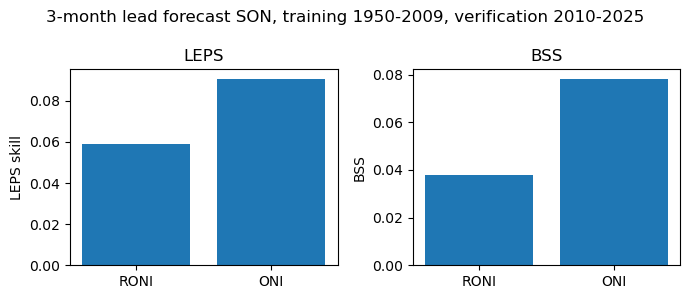

In [18]:
# 1-2. SKILL: split into 2-parts run 
Y = mp_son.copy() 
X1 = roni_amj[:-1].copy() # 3-month lead
X2 = oni_amj[:-1].copy()
scores = combo_method_SKL_train_test(X1,X2,Y,training_years=np.arange(1950,2010))
print (scores['years_training'], scores['years_verification'])
print()

fig, ax = plt.subplots(1, 2, figsize=(7, 3))

# LEPS
ax[0].bar(
    ['RONI', 'ONI'],
    [scores['roni']['LEPS skill'], scores['oni']['LEPS skill']]
)
ax[0].set_ylabel('LEPS skill')
ax[0].set_title('LEPS')

# BSS
ax[1].bar(
    ['RONI', 'ONI'],
    [scores['roni']['BSS'], scores['oni']['BSS']]
)
ax[1].set_ylabel('BSS')
ax[1].set_title('BSS')

fig.suptitle(
    '3-month lead forecast SON, training %d-%d, verification %d-%d'
    % (scores['years_training'][0], scores['years_training'][-1],
       scores['years_verification'][0], scores['years_verification'][-1])
) 

plt.tight_layout()
plt.show()


In [19]:
### Now validate with ###

# def combo_method_SKL_validation(X1,X2,Y,years,cv=LeaveOneOut()): 
#         Cross validate the Dine combo method
#         ARGS:
#             DF: dataframe with roni,oni, columns
#             years: list of entire years to validate (or range or ndarray)
#             cv: cross validator from sklearn with inherited "split" method
#                 default = LeaveOneOut() # uses future data 
#                 other options =  KFold(n_splits=n) # still uses future data
#                                  TimeSeriesSplit(n_splits=n, max_train_size =20, test_size=1) # does not use future data  
# in scores[], can retreive 'roni': score_roni,'oni': score_oni, 'years_training': years_tr,'years_verification': years_ver
# in scores[(r)oni][], can retreive 'contingency': contingency table, 'hit_count', 'miss_count', 'hit_years', 'miss_years'
# 'class_obs': observed tercile, 'class_pred': predicted tercile, 'prob_tn': probability assigned for t0 or t1 or t2 for corresponding year
# 'bias_tn', 'LEPS skill', 'BSS'

# 2-1. SKILL: standard LOOCV 
Y = mp_son.copy() 
X1 = roni_jja.copy() # 1-month lead
X2 = oni_jja.copy()
years = np.arange(1950,2026)
cv = LeaveOneOut()
scores = combo_method_SKL_validation(X1,X2,Y,years,cv)

# results for i iteration 
i = 3
print('Scores for LOOCV 1-month lead SON rainfall prediction')
print()
print(scores[i]['roni'])
print()
print(scores[i]['oni'])
print()
print(scores[i]['years_training'], scores[i]['years_verification'])


Scores for LOOCV 1-month lead SON rainfall prediction

{'contingency': array([[0, 1, 0],
       [0, 0, 0],
       [0, 0, 0]]), 'accuracy': 0.0, 'hit_count': 0, 'miss_count': 1, 'hit_years': array([], dtype=int64), 'miss_years': array([1953]), 'class_obs': array([1]), 'class_pred': array([0]), 'prob_t1': array([0.5174908], dtype=float32), 'prob_t2': array([0.37403917], dtype=float32), 'prob_t3': array([0.10847001], dtype=float32), 'bias_t1': inf, 'bias_t2': 0.0, 'bias_t3': nan, 'LEPS skill': 0.061058767139911624, 'BSS': -0.007084147691750475}

{'contingency': array([[0, 1, 0],
       [0, 0, 0],
       [0, 0, 0]]), 'accuracy': 0.0, 'hit_count': 0, 'miss_count': 1, 'hit_years': array([], dtype=int64), 'miss_years': array([1953]), 'class_obs': array([1]), 'class_pred': array([0]), 'prob_t1': array([0.4508501], dtype=float32), 'prob_t2': array([0.40682283], dtype=float32), 'prob_t3': array([0.14232706], dtype=float32), 'bias_t1': inf, 'bias_t2': 0.0, 'bias_t3': nan, 'LEPS skill': 0.11023425

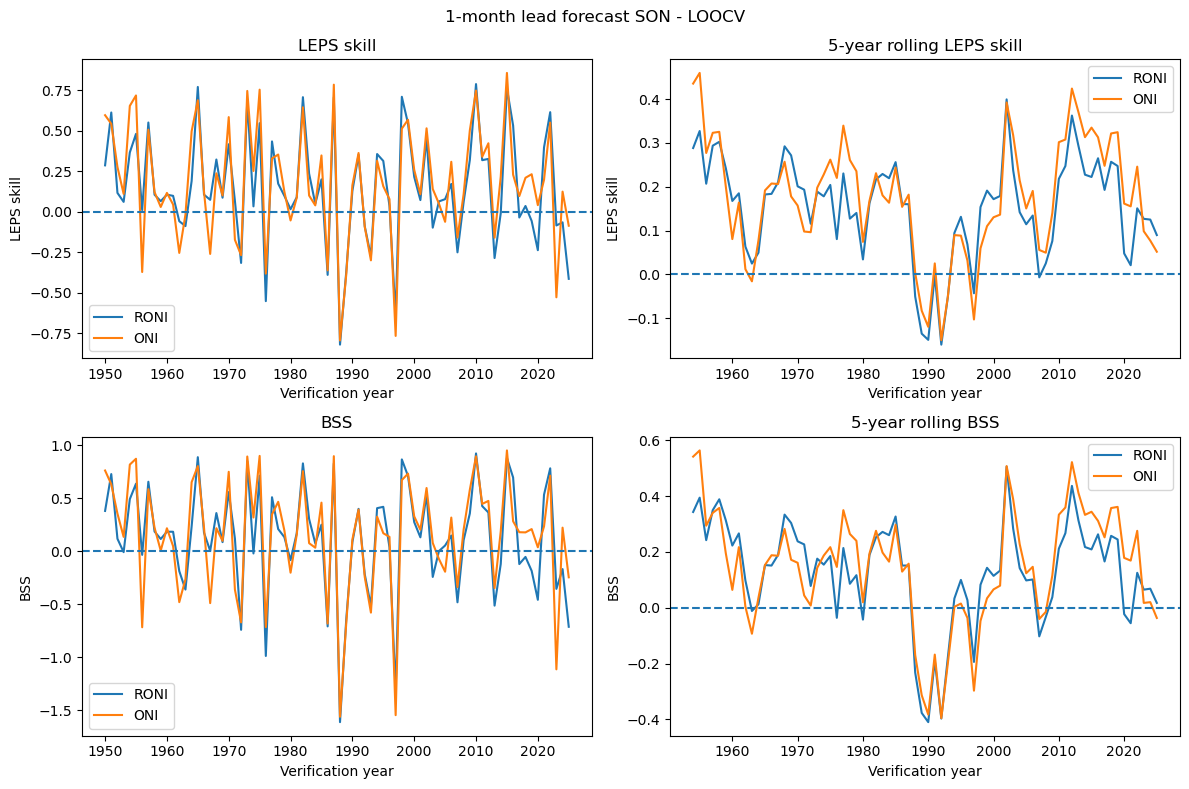

Mean RONI LEPS: 0.14958292210852742
Mean ONI LEPS: 0.1766563351789627
Mean RONI BSS: 0.12321972578269721
Mean ONI BSS: 0.14941988221196348


In [20]:
# Extract results from each iteration
years_ver = []
leps_roni = []
leps_oni = []
bss_roni = []
bss_oni = []

for score in scores:
    years_ver.append(score['years_verification'][0])

    leps_roni.append(score['roni']['LEPS skill'])
    leps_oni.append(score['oni']['LEPS skill'])

    bss_roni.append(score['roni']['BSS'])
    bss_oni.append(score['oni']['BSS'])


leps_roni_rolling = pd.Series(leps_roni).rolling(5).mean()
leps_oni_rolling = pd.Series(leps_oni).rolling(5).mean()

bss_roni_rolling = pd.Series(bss_roni).rolling(5).mean()
bss_oni_rolling = pd.Series(bss_oni).rolling(5).mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. LEPS by year
axes[0, 0].plot(years_ver, leps_roni, label='RONI')
axes[0, 0].plot(years_ver, leps_oni, label='ONI')
axes[0, 0].axhline(0, linestyle='--')
axes[0, 0].set_title('LEPS skill')
axes[0, 0].set_xlabel('Verification year')
axes[0, 0].set_ylabel('LEPS skill')
axes[0, 0].legend()

# 2. 5-year rolling LEPS
axes[0, 1].plot(years_ver, leps_roni_rolling, label='RONI')
axes[0, 1].plot(years_ver, leps_oni_rolling, label='ONI')
axes[0, 1].axhline(0, linestyle='--')
axes[0, 1].set_title('5-year rolling LEPS skill')
axes[0, 1].set_xlabel('Verification year')
axes[0, 1].set_ylabel('LEPS skill')
axes[0, 1].legend()

# 3. BSS by year
axes[1, 0].plot(years_ver, bss_roni, label='RONI')
axes[1, 0].plot(years_ver, bss_oni, label='ONI')
axes[1, 0].axhline(0, linestyle='--')
axes[1, 0].set_title('BSS')
axes[1, 0].set_xlabel('Verification year')
axes[1, 0].set_ylabel('BSS')
axes[1, 0].legend()

# 4. 5-year rolling BSS
axes[1, 1].plot(years_ver, bss_roni_rolling, label='RONI')
axes[1, 1].plot(years_ver, bss_oni_rolling, label='ONI')
axes[1, 1].axhline(0, linestyle='--')
axes[1, 1].set_title('5-year rolling BSS')
axes[1, 1].set_xlabel('Verification year')
axes[1, 1].set_ylabel('BSS')
axes[1, 1].legend()


fig.suptitle('1-month lead forecast SON - LOOCV') 
plt.tight_layout()
plt.show()


print('Mean RONI LEPS:', np.mean(leps_roni))
print('Mean ONI LEPS:', np.mean(leps_oni))

print('Mean RONI BSS:', np.mean(bss_roni))
print('Mean ONI BSS:', np.mean(bss_oni))

In [21]:
### Now validate with ###

# def combo_method_SKL_validation(X1,X2,Y,years,cv=LeaveOneOut()): 
#         Cross validate the Dine combo method
#         ARGS:
#             DF: dataframe with roni,oni, columns
#             years: list of entire years to validate (or range or ndarray)
#             cv: cross validator from sklearn with inherited "split" method
#                 default = LeaveOneOut() # uses future data 
#                 other options =  KFold(n_splits=n) # still uses future data
#                                  TimeSeriesSplit(n_splits=n, max_train_size =20, test_size=1) # does not use future data  
# in scores[], can retreive 'roni': score_roni,'oni': score_oni, 'years_training': years_tr,'years_verification': years_ver
# in scores[(r)oni][], can retreive 'contingency': contingency table, 'hit_count', 'miss_count', 'hit_years', 'miss_years'
# 'class_obs': observed tercile, 'class_pred': predicted tercile, 'prob_tn': probability assigned for t0 or t1 or t2 for corresponding year
# 'bias_tn', 'LEPS skill', 'BSS'

# 2-1. SKILL: standard LOOCV 
Y = mp_son.copy() 
X1 = roni_amj[:-1].copy() # 3-month lead
X2 = oni_amj[:-1].copy()
years = np.arange(1950,2026)
cv = LeaveOneOut()
scores = combo_method_SKL_validation(X1,X2,Y,years,cv)

# results for i iteration 
i = 1
print('Scores for LOOCV 3-month lead SON rainfall prediction')
print()
print(scores[i]['roni'])
print()
print(scores[i]['oni'])
print()
print(scores[i]['years_training'], scores[i]['years_verification'])


Scores for LOOCV 3-month lead SON rainfall prediction

{'contingency': array([[1, 0, 0],
       [0, 0, 0],
       [0, 0, 0]]), 'accuracy': 1.0, 'hit_count': 1, 'miss_count': 0, 'hit_years': array([1951]), 'miss_years': array([], dtype=int64), 'class_obs': array([0]), 'class_pred': array([0]), 'prob_t1': array([0.41785866], dtype=float32), 'prob_t2': array([0.33003268], dtype=float32), 'prob_t3': array([0.25210863], dtype=float32), 'bias_t1': 1.0, 'bias_t2': nan, 'bias_t3': nan, 'LEPS skill': 0.15600952133536336, 'BSS': 0.23294669484360375}

{'contingency': array([[0, 0, 0],
       [1, 0, 0],
       [0, 0, 0]]), 'accuracy': 0.0, 'hit_count': 0, 'miss_count': 1, 'hit_years': array([], dtype=int64), 'miss_years': array([1951]), 'class_obs': array([0]), 'class_pred': array([1]), 'prob_t1': array([0.31171846], dtype=float32), 'prob_t2': array([0.35137928], dtype=float32), 'prob_t3': array([0.33690226], dtype=float32), 'bias_t1': 0.0, 'bias_t2': inf, 'bias_t3': nan, 'LEPS skill': -0.03084962

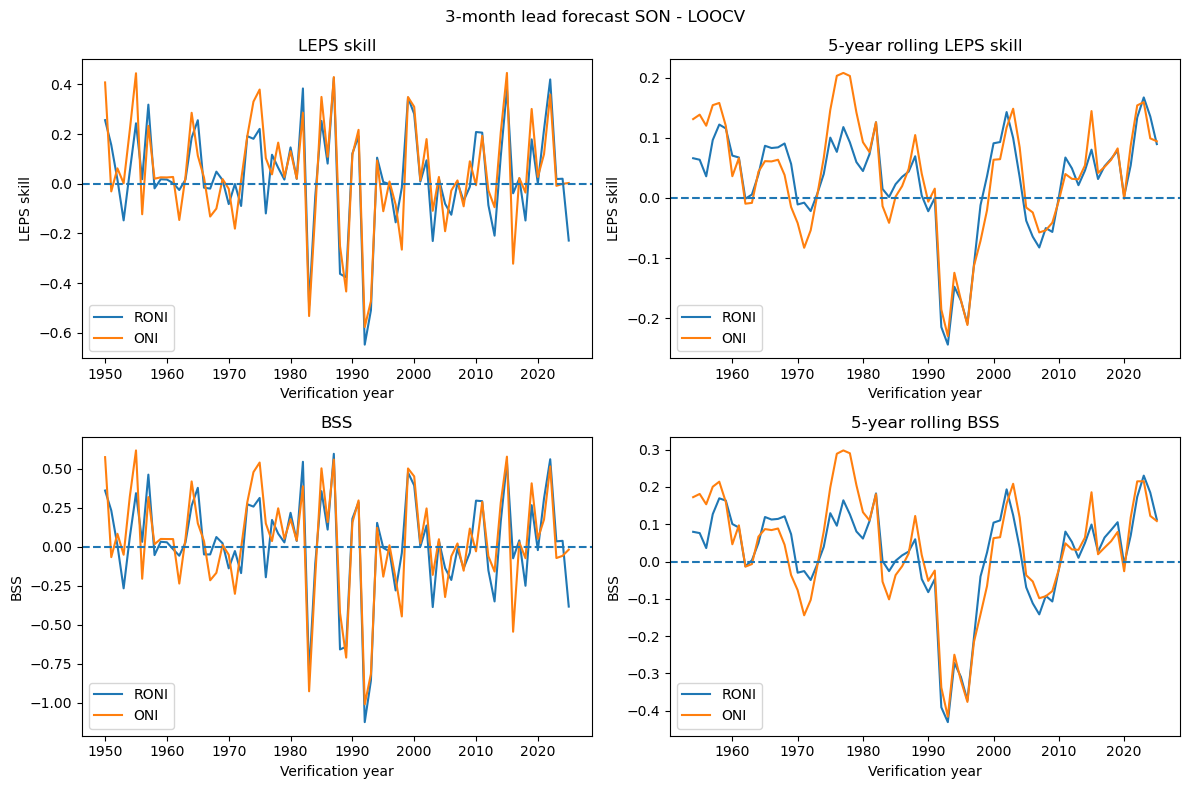

Mean RONI LEPS: 0.0305518625948326
Mean ONI LEPS: 0.04099539703605487
Mean RONI BSS: 0.02361301446425844
Mean ONI BSS: 0.036191034582886895


In [22]:
# Extract results from each iteration
years_ver = []
leps_roni = []
leps_oni = []
bss_roni = []
bss_oni = []

for score in scores:
    years_ver.append(score['years_verification'][0])

    leps_roni.append(score['roni']['LEPS skill'])
    leps_oni.append(score['oni']['LEPS skill'])

    bss_roni.append(score['roni']['BSS'])
    bss_oni.append(score['oni']['BSS'])


leps_roni_rolling = pd.Series(leps_roni).rolling(5).mean()
leps_oni_rolling = pd.Series(leps_oni).rolling(5).mean()

bss_roni_rolling = pd.Series(bss_roni).rolling(5).mean()
bss_oni_rolling = pd.Series(bss_oni).rolling(5).mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. LEPS by year
axes[0, 0].plot(years_ver, leps_roni, label='RONI')
axes[0, 0].plot(years_ver, leps_oni, label='ONI')
axes[0, 0].axhline(0, linestyle='--')
axes[0, 0].set_title('LEPS skill')
axes[0, 0].set_xlabel('Verification year')
axes[0, 0].set_ylabel('LEPS skill')
axes[0, 0].legend()

# 2. 5-year rolling LEPS
axes[0, 1].plot(years_ver, leps_roni_rolling, label='RONI')
axes[0, 1].plot(years_ver, leps_oni_rolling, label='ONI')
axes[0, 1].axhline(0, linestyle='--')
axes[0, 1].set_title('5-year rolling LEPS skill')
axes[0, 1].set_xlabel('Verification year')
axes[0, 1].set_ylabel('LEPS skill')
axes[0, 1].legend()

# 3. BSS by year
axes[1, 0].plot(years_ver, bss_roni, label='RONI')
axes[1, 0].plot(years_ver, bss_oni, label='ONI')
axes[1, 0].axhline(0, linestyle='--')
axes[1, 0].set_title('BSS')
axes[1, 0].set_xlabel('Verification year')
axes[1, 0].set_ylabel('BSS')
axes[1, 0].legend()

# 4. 5-year rolling BSS
axes[1, 1].plot(years_ver, bss_roni_rolling, label='RONI')
axes[1, 1].plot(years_ver, bss_oni_rolling, label='ONI')
axes[1, 1].axhline(0, linestyle='--')
axes[1, 1].set_title('5-year rolling BSS')
axes[1, 1].set_xlabel('Verification year')
axes[1, 1].set_ylabel('BSS')
axes[1, 1].legend()


fig.suptitle('3-month lead forecast SON - LOOCV') 
plt.tight_layout()
plt.show()




print('Mean RONI LEPS:', np.mean(leps_roni))
print('Mean ONI LEPS:', np.mean(leps_oni))

print('Mean RONI BSS:', np.mean(bss_roni))
print('Mean ONI BSS:', np.mean(bss_oni))

In [23]:
### Now validate with ###

# def combo_method_SKL_validation(X1,X2,Y,years,cv=LeaveOneOut()): 
#         Cross validate the Dine combo method
#         ARGS:
#             DF: dataframe with roni,oni, columns
#             years: list of entire years to validate (or range or ndarray)
#             cv: cross validator from sklearn with inherited "split" method
#                 default = LeaveOneOut() # uses future data 
#                 other options =  KFold(n_splits=n) # still uses future data
#                                  TimeSeriesSplit(n_splits=n, max_train_size =20, test_size=1) # does not use future data  
# in scores[], can retreive 'roni': score_roni,'oni': score_oni, 'years_training': years_tr,'years_verification': years_ver
# in scores[(r)oni][], can retreive 'contingency': contingency table, 'hit_count', 'miss_count', 'hit_years', 'miss_years'
# 'class_obs': observed tercile, 'class_pred': predicted tercile, 'prob_tn': probability assigned for t0 or t1 or t2 for corresponding year
# 'bias_tn', 'LEPS skill', 'BSS'

# 2-2. SKILL: standard k-fold 
Y = mp_son.copy() 
X1 = roni_jja.copy() # 1-month lead
X2 = oni_jja.copy()
years = np.arange(1950,2026)
cv = KFold(n_splits = 4)
scores = combo_method_SKL_validation(X1,X2,Y,years,cv)

# results for i iteration 
i = 3
print('Scores for 4-fold 1-month lead SON rainfall prediction')
print()
print(scores[i]['roni'])
print()
print(scores[i]['oni'])
print()
print(scores[i]['years_training'], scores[i]['years_verification'])


Scores for 4-fold 1-month lead SON rainfall prediction

{'contingency': array([[3, 1, 0],
       [3, 0, 0],
       [3, 4, 5]]), 'accuracy': 0.42105263157894735, 'hit_count': 8, 'miss_count': 11, 'hit_years': array([2009, 2010, 2011, 2012, 2015, 2016, 2021, 2022]), 'miss_years': array([2007, 2008, 2013, 2014, 2017, 2018, 2019, 2020, 2023, 2024, 2025]), 'class_obs': array([1, 1, 0, 2, 2, 0, 0, 0, 0, 2, 1, 0, 0, 0, 2, 2, 1, 1, 0]), 'class_pred': array([2, 2, 0, 2, 2, 0, 2, 1, 0, 2, 2, 1, 1, 2, 2, 2, 0, 2, 2]), 'prob_t1': array([0.05168164, 0.17211302, 0.4672756 , 0.00689069, 0.09180652,
       0.4725723 , 0.13609836, 0.2478303 , 0.8593098 , 0.03855054,
       0.09854613, 0.27216667, 0.22558174, 0.05376257, 0.06882054,
       0.02497106, 0.69791186, 0.08981548, 0.09683507], dtype=float32), 'prob_t2': array([0.28154996, 0.40284038, 0.38395202, 0.12059239, 0.34276456,
       0.38183522, 0.38267022, 0.42270258, 0.13062198, 0.25183827,
       0.35025492, 0.42433465, 0.4194036 , 0.28567043, 0.3

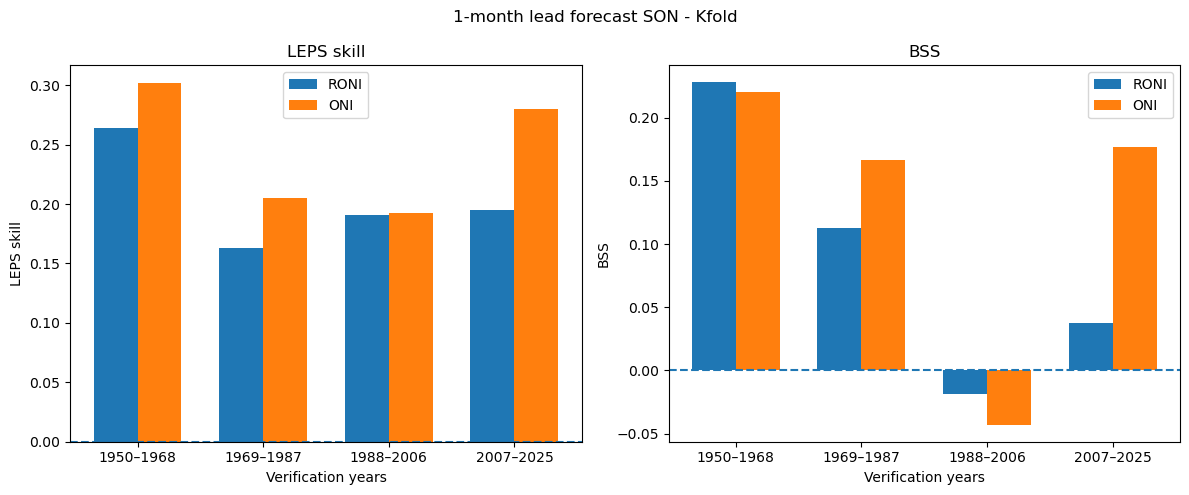

Mean RONI LEPS: 0.20323053314395528
Mean ONI LEPS: 0.2447422086358461
Mean RONI BSS: 0.0897279332611341
Mean ONI BSS: 0.13018196206090055


In [24]:
# Extract results from each iteration
fold_labels = []
leps_roni = []
leps_oni = []
bss_roni = []
bss_oni = []

for i, score in enumerate(scores):

    years_ver = score['years_verification']

    # label each fold by its verification period
    fold_labels.append(
        f"{years_ver[0]}–{years_ver[-1]}"
    )

    leps_roni.append(score['roni']['LEPS skill'])
    leps_oni.append(score['oni']['LEPS skill'])

    bss_roni.append(score['roni']['BSS'])
    bss_oni.append(score['oni']['BSS'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(len(fold_labels))
width = 0.35

# LEPS
axes[0].bar(x - width/2, leps_roni, width, label='RONI')
axes[0].bar(x + width/2, leps_oni, width, label='ONI')

axes[0].axhline(0, linestyle='--')
axes[0].set_xticks(x)
axes[0].set_xticklabels(fold_labels)
axes[0].set_xlabel('Verification years')
axes[0].set_ylabel('LEPS skill')
axes[0].set_title('LEPS skill')
axes[0].legend()


# BSS
axes[1].bar(x - width/2, bss_roni, width, label='RONI')
axes[1].bar(x + width/2, bss_oni, width, label='ONI')

axes[1].axhline(0, linestyle='--')
axes[1].set_xticks(x)
axes[1].set_xticklabels(fold_labels)
axes[1].set_xlabel('Verification years')
axes[1].set_ylabel('BSS')
axes[1].set_title('BSS')
axes[1].legend()

fig.suptitle('1-month lead forecast SON - Kfold') 

plt.tight_layout()
plt.show()

print('Mean RONI LEPS:', np.mean(leps_roni))
print('Mean ONI LEPS:', np.mean(leps_oni))

print('Mean RONI BSS:', np.mean(bss_roni))
print('Mean ONI BSS:', np.mean(bss_oni))

In [25]:
### Now validate with ###

# def combo_method_SKL_validation(X1,X2,Y,years,cv=LeaveOneOut()): 
#         Cross validate the Dine combo method
#         ARGS:
#             DF: dataframe with roni,oni, columns
#             years: list of entire years to validate (or range or ndarray)
#             cv: cross validator from sklearn with inherited "split" method
#                 default = LeaveOneOut() # uses future data 
#                 other options =  KFold(n_splits=n) # still uses future data
#                                  TimeSeriesSplit(n_splits=n, max_train_size =20, test_size=1) # does not use future data  
# in scores[], can retreive 'roni': score_roni,'oni': score_oni, 'years_training': years_tr,'years_verification': years_ver
# in scores[(r)oni][], can retreive 'contingency': contingency table, 'hit_count', 'miss_count', 'hit_years', 'miss_years'
# 'class_obs': observed tercile, 'class_pred': predicted tercile, 'prob_tn': probability assigned for t0 or t1 or t2 for corresponding year
# 'bias_tn', 'LEPS skill', 'BSS'

# 2-2. SKILL: standard k-fold 
Y = mp_son.copy() 
X1 = roni_amj[:-1].copy() # 3-month lead
X2 = oni_amj[:-1].copy()
years = np.arange(1950,2026)
cv = KFold(n_splits = 4)
scores = combo_method_SKL_validation(X1,X2,Y,years,cv)

# results for i iteration 
i = 3
print('Scores for 4-fold 3-month lead SON rainfall prediction')
print()
print(scores[i]['roni'])
print()
print(scores[i]['oni'])
print()
print(scores[i]['years_training'], scores[i]['years_verification'])

Scores for 4-fold 3-month lead SON rainfall prediction

{'contingency': array([[3, 0, 0],
       [1, 2, 1],
       [5, 3, 4]]), 'accuracy': 0.47368421052631576, 'hit_count': 9, 'miss_count': 10, 'hit_years': array([2010, 2011, 2014, 2015, 2017, 2019, 2021, 2022, 2023]), 'miss_years': array([2007, 2008, 2009, 2012, 2013, 2016, 2018, 2020, 2024, 2025]), 'class_obs': array([1, 1, 0, 2, 2, 0, 0, 0, 0, 2, 1, 0, 0, 0, 2, 2, 1, 1, 0]), 'class_pred': array([2, 2, 1, 2, 2, 2, 2, 0, 0, 1, 1, 2, 0, 2, 2, 2, 1, 2, 2]), 'prob_t1': array([0.22885664, 0.17606367, 0.3071697 , 0.20183723, 0.20301872,
       0.27660897, 0.22958292, 0.36965734, 0.5362154 , 0.32326713,
       0.3001478 , 0.2523431 , 0.40813982, 0.22327837, 0.1970744 ,
       0.11187781, 0.33649433, 0.2861202 , 0.22244333], dtype=float32), 'prob_t2': array([0.3572578 , 0.35499245, 0.34912428, 0.3570729 , 0.35712078,
       0.35361797, 0.35723817, 0.3357358 , 0.27940652, 0.34617913,
       0.35028854, 0.3560359 , 0.32512504, 0.35736817, 0.3

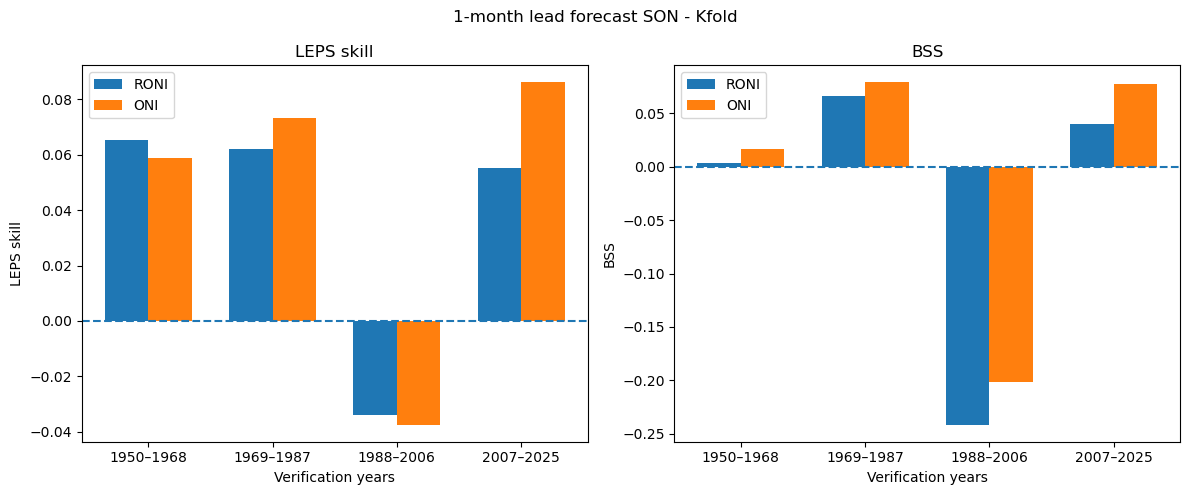

Mean RONI LEPS: 0.03709596302351448
Mean ONI LEPS: 0.04509533602584277
Mean RONI BSS: -0.03283722239763355
Mean ONI BSS: -0.0071448660279314


In [26]:
# Extract results from each iteration
fold_labels = []
leps_roni = []
leps_oni = []
bss_roni = []
bss_oni = []

for i, score in enumerate(scores):

    years_ver = score['years_verification']

    # label each fold by its verification period
    fold_labels.append(
        f"{years_ver[0]}–{years_ver[-1]}"
    )

    leps_roni.append(score['roni']['LEPS skill'])
    leps_oni.append(score['oni']['LEPS skill'])

    bss_roni.append(score['roni']['BSS'])
    bss_oni.append(score['oni']['BSS'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(len(fold_labels))
width = 0.35

# LEPS
axes[0].bar(x - width/2, leps_roni, width, label='RONI')
axes[0].bar(x + width/2, leps_oni, width, label='ONI')

axes[0].axhline(0, linestyle='--')
axes[0].set_xticks(x)
axes[0].set_xticklabels(fold_labels)
axes[0].set_xlabel('Verification years')
axes[0].set_ylabel('LEPS skill')
axes[0].set_title('LEPS skill')
axes[0].legend()


# BSS
axes[1].bar(x - width/2, bss_roni, width, label='RONI')
axes[1].bar(x + width/2, bss_oni, width, label='ONI')

axes[1].axhline(0, linestyle='--')
axes[1].set_xticks(x)
axes[1].set_xticklabels(fold_labels)
axes[1].set_xlabel('Verification years')
axes[1].set_ylabel('BSS')
axes[1].set_title('BSS')
axes[1].legend()

fig.suptitle('1-month lead forecast SON - Kfold') 

plt.tight_layout()
plt.show()

print('Mean RONI LEPS:', np.mean(leps_roni))
print('Mean ONI LEPS:', np.mean(leps_oni))

print('Mean RONI BSS:', np.mean(bss_roni))
print('Mean ONI BSS:', np.mean(bss_oni))

In [27]:
### Now validate with ###

# def combo_method_SKL_validation(X1,X2,Y,years,cv=LeaveOneOut()): 
#         Cross validate the Dine combo method
#         ARGS:
#             DF: dataframe with roni,oni, columns
#             years: list of entire years to validate (or range or ndarray)
#             cv: cross validator from sklearn with inherited "split" method
#                 default = LeaveOneOut() # uses future data 
#                 other options =  KFold(n_splits=n) # still uses future data
#                                  TimeSeriesSplit(n_splits=n, max_train_size =20, test_size=1) # does not use future data  
# in scores[], can retreive 'roni': score_roni,'oni': score_oni, 'years_training': years_tr,'years_verification': years_ver
# in scores[(r)oni][], can retreive 'contingency': contingency table, 'hit_count', 'miss_count', 'hit_years', 'miss_years'
# 'class_obs': observed tercile, 'class_pred': predicted tercile, 'prob_tn': probability assigned for t0 or t1 or t2 for corresponding year
# 'bias_tn', 'LEPS skill', 'BSS'

# 3-1. SKILL: timeseries split (expanding training set)
Y = mp_son.copy() 
X1 = roni_jja.copy() # 1-month lead
X2 = oni_jja.copy()
years = np.arange(1950,2026)
cv = TimeSeriesSplit(n_splits = 51)
scores = combo_method_SKL_validation(X1,X2,Y,years,cv)

# results for i iteration 
i = 2
print('Scores for Timeseriessplit  1-month lead SON rainfall prediction')
print()
print(scores[i]['roni'])
print()
print(scores[i]['oni'])
print()
print(scores[i]['years_training'], scores[i]['years_verification'])

Scores for Timeseriessplit  1-month lead SON rainfall prediction

{'contingency': array([[1, 0, 0],
       [0, 0, 0],
       [0, 0, 0]]), 'accuracy': 1.0, 'hit_count': 1, 'miss_count': 0, 'hit_years': array([1977]), 'miss_years': array([], dtype=int64), 'class_obs': array([0]), 'class_pred': array([0]), 'prob_t1': array([0.5932142], dtype=float32), 'prob_t2': array([0.34397483], dtype=float32), 'prob_t3': array([0.06281103], dtype=float32), 'bias_t1': 1.0, 'bias_t2': nan, 'bias_t3': nan, 'LEPS skill': 0.49525770731270313, 'BSS': 0.5683921234880633}

{'contingency': array([[1, 0, 0],
       [0, 0, 0],
       [0, 0, 0]]), 'accuracy': 1.0, 'hit_count': 1, 'miss_count': 0, 'hit_years': array([1977]), 'miss_years': array([], dtype=int64), 'class_obs': array([0]), 'class_pred': array([0]), 'prob_t1': array([0.57690626], dtype=float32), 'prob_t2': array([0.37052777], dtype=float32), 'prob_t3': array([0.05256598], dtype=float32), 'bias_t1': 1.0, 'bias_t2': nan, 'bias_t3': nan, 'LEPS skill': 0.

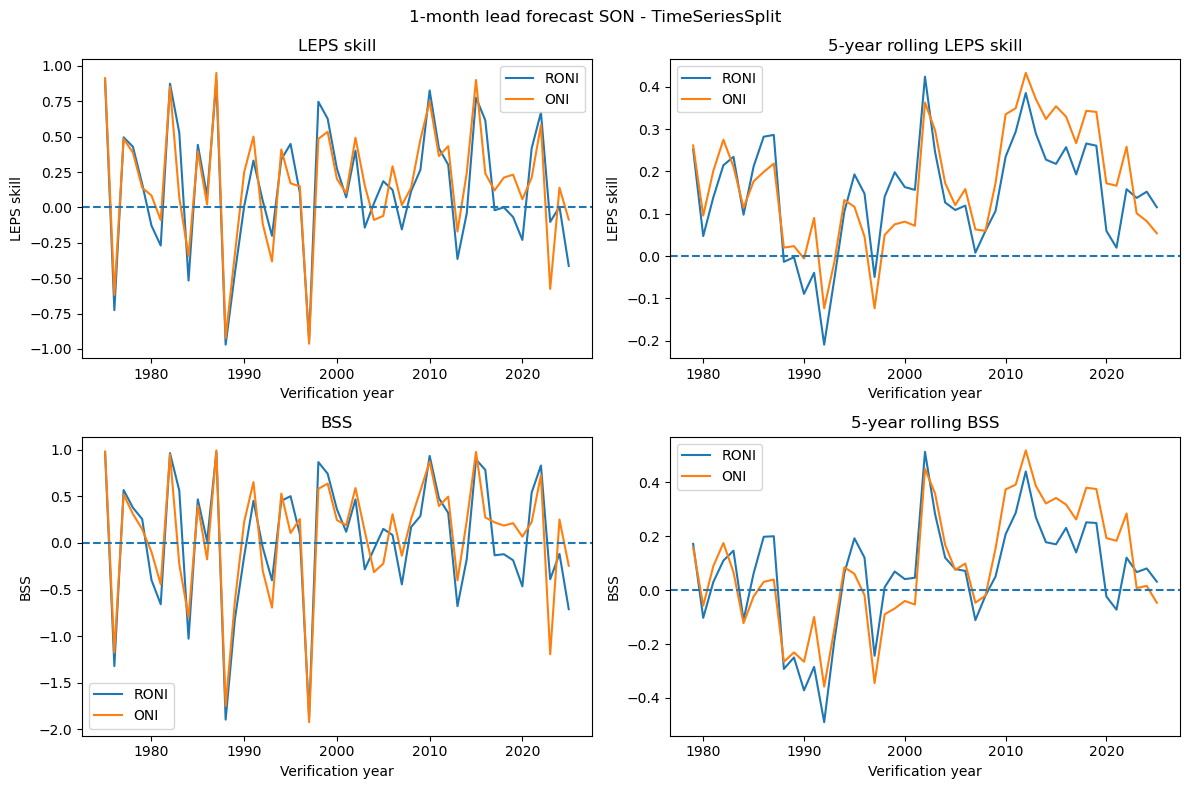

Mean RONI LEPS: 0.1413743378220448
Mean ONI LEPS: 0.16497815417404466
Mean RONI BSS: 0.04677031740627349
Mean ONI BSS: 0.0788743049008147


In [28]:
# Extract results from each iteration
years_ver = []
leps_roni = []
leps_oni = []
bss_roni = []
bss_oni = []

for score in scores:
    years_ver.append(score['years_verification'][0])

    leps_roni.append(score['roni']['LEPS skill'])
    leps_oni.append(score['oni']['LEPS skill'])

    bss_roni.append(score['roni']['BSS'])
    bss_oni.append(score['oni']['BSS'])


leps_roni_rolling = pd.Series(leps_roni).rolling(5).mean()
leps_oni_rolling = pd.Series(leps_oni).rolling(5).mean()

bss_roni_rolling = pd.Series(bss_roni).rolling(5).mean()
bss_oni_rolling = pd.Series(bss_oni).rolling(5).mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. LEPS by year
axes[0, 0].plot(years_ver, leps_roni, label='RONI')
axes[0, 0].plot(years_ver, leps_oni, label='ONI')
axes[0, 0].axhline(0, linestyle='--')
axes[0, 0].set_title('LEPS skill')
axes[0, 0].set_xlabel('Verification year')
axes[0, 0].set_ylabel('LEPS skill')
axes[0, 0].legend()

# 2. 5-year rolling LEPS
axes[0, 1].plot(years_ver, leps_roni_rolling, label='RONI')
axes[0, 1].plot(years_ver, leps_oni_rolling, label='ONI')
axes[0, 1].axhline(0, linestyle='--')
axes[0, 1].set_title('5-year rolling LEPS skill')
axes[0, 1].set_xlabel('Verification year')
axes[0, 1].set_ylabel('LEPS skill')
axes[0, 1].legend()

# 3. BSS by year
axes[1, 0].plot(years_ver, bss_roni, label='RONI')
axes[1, 0].plot(years_ver, bss_oni, label='ONI')
axes[1, 0].axhline(0, linestyle='--')
axes[1, 0].set_title('BSS')
axes[1, 0].set_xlabel('Verification year')
axes[1, 0].set_ylabel('BSS')
axes[1, 0].legend()

# 4. 5-year rolling BSS
axes[1, 1].plot(years_ver, bss_roni_rolling, label='RONI')
axes[1, 1].plot(years_ver, bss_oni_rolling, label='ONI')
axes[1, 1].axhline(0, linestyle='--')
axes[1, 1].set_title('5-year rolling BSS')
axes[1, 1].set_xlabel('Verification year')
axes[1, 1].set_ylabel('BSS')
axes[1, 1].legend()


fig.suptitle('1-month lead forecast SON - TimeSeriesSplit') 
plt.tight_layout()
plt.show()




print('Mean RONI LEPS:', np.mean(leps_roni))
print('Mean ONI LEPS:', np.mean(leps_oni))

print('Mean RONI BSS:', np.mean(bss_roni))
print('Mean ONI BSS:', np.mean(bss_oni))

In [29]:
### Now validate with ###

# def combo_method_SKL_validation(X1,X2,Y,years,cv=LeaveOneOut()): 
#         Cross validate the Dine combo method
#         ARGS:
#             DF: dataframe with roni,oni, columns
#             years: list of entire years to validate (or range or ndarray)
#             cv: cross validator from sklearn with inherited "split" method
#                 default = LeaveOneOut() # uses future data 
#                 other options =  KFold(n_splits=n) # still uses future data
#                                  TimeSeriesSplit(n_splits=n, max_train_size =20, test_size=1) # does not use future data  
# in scores[], can retreive 'roni': score_roni,'oni': score_oni, 'years_training': years_tr,'years_verification': years_ver
# in scores[(r)oni][], can retreive 'contingency': contingency table, 'hit_count', 'miss_count', 'hit_years', 'miss_years'
# 'class_obs': observed tercile, 'class_pred': predicted tercile, 'prob_tn': probability assigned for t0 or t1 or t2 for corresponding year
# 'bias_tn', 'LEPS skill', 'BSS'

# 3-2. SKILL: timeseries split (expanding training set)
Y = mp_son.copy() 
X1 = roni_amj[:-1].copy() # 3-month lead
X2 = oni_amj[:-1].copy()
years = np.arange(1950,2026)
cv = TimeSeriesSplit(n_splits = 51)
scores = combo_method_SKL_validation(X1,X2,Y,years,cv)

# results for i iteration 
i = -1
print('Scores for Timeseriessplit  3-month lead SON rainfall prediction')
print()
print(scores[i]['roni'])
print()
print(scores[i]['oni'])
print()
print(scores[i]['years_training'], scores[i]['years_verification'])

Scores for Timeseriessplit  3-month lead SON rainfall prediction

{'contingency': array([[0, 0, 0],
       [0, 0, 0],
       [1, 0, 0]]), 'accuracy': 0.0, 'hit_count': 0, 'miss_count': 1, 'hit_years': array([], dtype=int64), 'miss_years': array([2025]), 'class_obs': array([0]), 'class_pred': array([2]), 'prob_t1': array([0.21701081], dtype=float32), 'prob_t2': array([0.3573081], dtype=float32), 'prob_t3': array([0.42568105], dtype=float32), 'bias_t1': 0.0, 'bias_t2': nan, 'bias_t3': inf, 'LEPS skill': -0.22871271201542448, 'BSS': -0.3829182520449319}

{'contingency': array([[0, 0, 0],
       [1, 0, 0],
       [0, 0, 0]]), 'accuracy': 0.0, 'hit_count': 0, 'miss_count': 1, 'hit_years': array([], dtype=int64), 'miss_years': array([2025]), 'class_obs': array([0]), 'class_pred': array([1]), 'prob_t1': array([0.3276417], dtype=float32), 'prob_t2': array([0.35150778], dtype=float32), 'prob_t3': array([0.32085055], dtype=float32), 'bias_t1': 0.0, 'bias_t2': inf, 'bias_t3': nan, 'LEPS skill': 0

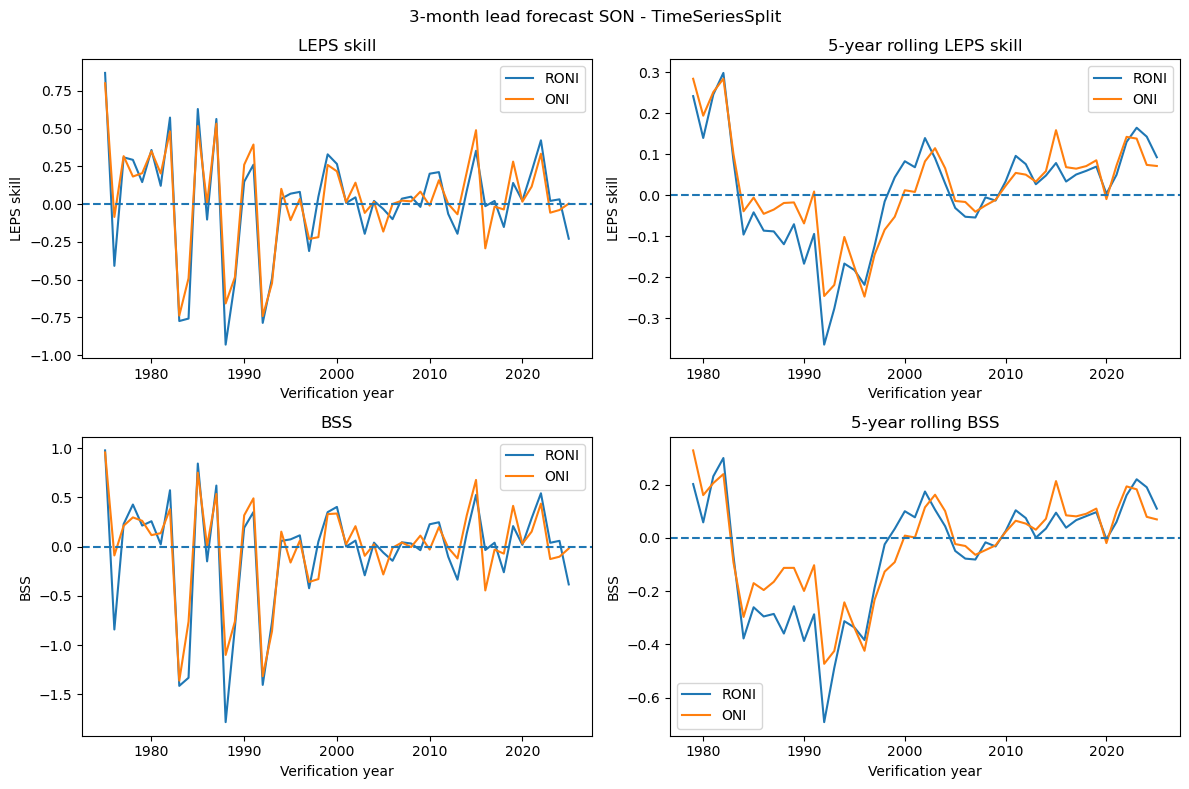

Mean RONI LEPS: 0.017896732427108073
Mean ONI LEPS: 0.03392020484816717
Mean RONI BSS: -0.04452293864173285
Mean ONI BSS: -0.00828595358293478


In [30]:
# Extract results from each iteration
years_ver = []
leps_roni = []
leps_oni = []
bss_roni = []
bss_oni = []

for score in scores:
    years_ver.append(score['years_verification'][0])

    leps_roni.append(score['roni']['LEPS skill'])
    leps_oni.append(score['oni']['LEPS skill'])

    bss_roni.append(score['roni']['BSS'])
    bss_oni.append(score['oni']['BSS'])


leps_roni_rolling = pd.Series(leps_roni).rolling(5).mean()
leps_oni_rolling = pd.Series(leps_oni).rolling(5).mean()

bss_roni_rolling = pd.Series(bss_roni).rolling(5).mean()
bss_oni_rolling = pd.Series(bss_oni).rolling(5).mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. LEPS by year
axes[0, 0].plot(years_ver, leps_roni, label='RONI')
axes[0, 0].plot(years_ver, leps_oni, label='ONI')
axes[0, 0].axhline(0, linestyle='--')
axes[0, 0].set_title('LEPS skill')
axes[0, 0].set_xlabel('Verification year')
axes[0, 0].set_ylabel('LEPS skill')
axes[0, 0].legend()

# 2. 5-year rolling LEPS
axes[0, 1].plot(years_ver, leps_roni_rolling, label='RONI')
axes[0, 1].plot(years_ver, leps_oni_rolling, label='ONI')
axes[0, 1].axhline(0, linestyle='--')
axes[0, 1].set_title('5-year rolling LEPS skill')
axes[0, 1].set_xlabel('Verification year')
axes[0, 1].set_ylabel('LEPS skill')
axes[0, 1].legend()

# 3. BSS by year
axes[1, 0].plot(years_ver, bss_roni, label='RONI')
axes[1, 0].plot(years_ver, bss_oni, label='ONI')
axes[1, 0].axhline(0, linestyle='--')
axes[1, 0].set_title('BSS')
axes[1, 0].set_xlabel('Verification year')
axes[1, 0].set_ylabel('BSS')
axes[1, 0].legend()

# 4. 5-year rolling BSS
axes[1, 1].plot(years_ver, bss_roni_rolling, label='RONI')
axes[1, 1].plot(years_ver, bss_oni_rolling, label='ONI')
axes[1, 1].axhline(0, linestyle='--')
axes[1, 1].set_title('5-year rolling BSS')
axes[1, 1].set_xlabel('Verification year')
axes[1, 1].set_ylabel('BSS')
axes[1, 1].legend()


fig.suptitle('3-month lead forecast SON - TimeSeriesSplit') 
plt.tight_layout()
plt.show()




print('Mean RONI LEPS:', np.mean(leps_roni))
print('Mean ONI LEPS:', np.mean(leps_oni))

print('Mean RONI BSS:', np.mean(bss_roni))
print('Mean ONI BSS:', np.mean(bss_oni))

In [38]:
### Now validate with ###

# def combo_method_SKL_validation(X1,X2,Y,years,cv=LeaveOneOut()): 
#         Cross validate the Dine combo method
#         ARGS:
#             DF: dataframe with roni,oni, columns
#             years: list of entire years to validate (or range or ndarray)
#             cv: cross validator from sklearn with inherited "split" method
#                 default = LeaveOneOut() # uses future data 
#                 other options =  KFold(n_splits=n) # still uses future data
#                                  TimeSeriesSplit(n_splits=n, max_train_size =20, test_size=1) # does not use future data  
# in scores[], can retreive 'roni': score_roni,'oni': score_oni, 'years_training': years_tr,'years_verification': years_ver
# in scores[(r)oni][], can retreive 'contingency': contingency table, 'hit_count', 'miss_count', 'hit_years', 'miss_years'
# 'class_obs': observed tercile, 'class_pred': predicted tercile, 'prob_tn': probability assigned for t0 or t1 or t2 for corresponding year
# 'bias_tn', 'LEPS skill', 'BSS'

# 4-1. SKILL: sliding window 
Y = mp_son.copy() 
X1 = roni_jja.copy() # 1-month lead
X2 = oni_jja.copy()
years = np.arange(1950,2026)
cv = TimeSeriesSplit(n_splits = 51, max_train_size = 25, test_size = 1)
scores = combo_method_SKL_validation(X1,X2,Y,years,cv)

# results for i iteration 
i = -1
print('Scores for sliding window  1-month lead SON rainfall prediction')
print()
print(scores[i]['roni'])
print()
print(scores[i]['oni'])
print()
print(scores[i]['years_training'], scores[i]['years_verification'])



# print(scores[0]['years_training'], scores[0]['years_verification'])
# print(scores[1]['years_training'], scores[1]['years_verification'])
# print(scores[2]['years_training'], scores[2]['years_verification'])

Scores for sliding window  1-month lead SON rainfall prediction

{'contingency': array([[0, 0, 0],
       [0, 0, 0],
       [1, 0, 0]]), 'accuracy': 0.0, 'hit_count': 0, 'miss_count': 1, 'hit_years': array([], dtype=int64), 'miss_years': array([2025]), 'class_obs': array([0]), 'class_pred': array([2]), 'prob_t1': array([0.18051119], dtype=float32), 'prob_t2': array([0.363105], dtype=float32), 'prob_t3': array([0.4563838], dtype=float32), 'bias_t1': 0.0, 'bias_t2': nan, 'bias_t3': inf, 'LEPS skill': -0.3019574327128274, 'BSS': -0.5175399733222246}

{'contingency': array([[0, 0, 0],
       [1, 0, 0],
       [0, 0, 0]]), 'accuracy': 0.0, 'hit_count': 0, 'miss_count': 1, 'hit_years': array([], dtype=int64), 'miss_years': array([2025]), 'class_obs': array([0]), 'class_pred': array([1]), 'prob_t1': array([0.25022262], dtype=float32), 'prob_t2': array([0.37928146], dtype=float32), 'prob_t3': array([0.37049592], dtype=float32), 'bias_t1': 0.0, 'bias_t2': inf, 'bias_t3': nan, 'LEPS skill': -0.1

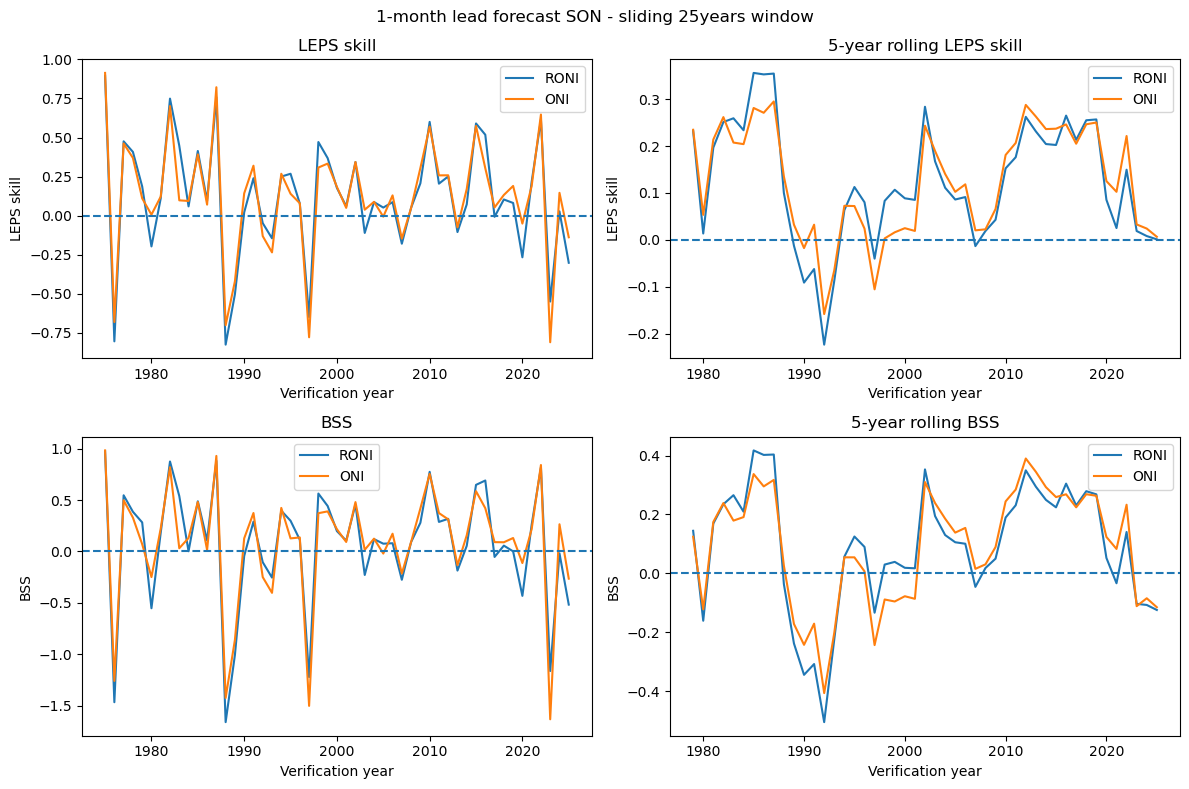

Mean RONI LEPS: 0.11627975838822271
Mean ONI LEPS: 0.12244498154059354
Mean RONI BSS: 0.06825192725903288
Mean ONI BSS: 0.07783293267179943


In [32]:
# Extract results from each iteration
years_ver = []
leps_roni = []
leps_oni = []
bss_roni = []
bss_oni = []

for score in scores:
    years_ver.append(score['years_verification'][0])

    leps_roni.append(score['roni']['LEPS skill'])
    leps_oni.append(score['oni']['LEPS skill'])

    bss_roni.append(score['roni']['BSS'])
    bss_oni.append(score['oni']['BSS'])


leps_roni_rolling = pd.Series(leps_roni).rolling(5).mean()
leps_oni_rolling = pd.Series(leps_oni).rolling(5).mean()

bss_roni_rolling = pd.Series(bss_roni).rolling(5).mean()
bss_oni_rolling = pd.Series(bss_oni).rolling(5).mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. LEPS by year
axes[0, 0].plot(years_ver, leps_roni, label='RONI')
axes[0, 0].plot(years_ver, leps_oni, label='ONI')
axes[0, 0].axhline(0, linestyle='--')
axes[0, 0].set_title('LEPS skill')
axes[0, 0].set_xlabel('Verification year')
axes[0, 0].set_ylabel('LEPS skill')
axes[0, 0].legend()

# 2. 5-year rolling LEPS
axes[0, 1].plot(years_ver, leps_roni_rolling, label='RONI')
axes[0, 1].plot(years_ver, leps_oni_rolling, label='ONI')
axes[0, 1].axhline(0, linestyle='--')
axes[0, 1].set_title('5-year rolling LEPS skill')
axes[0, 1].set_xlabel('Verification year')
axes[0, 1].set_ylabel('LEPS skill')
axes[0, 1].legend()

# 3. BSS by year
axes[1, 0].plot(years_ver, bss_roni, label='RONI')
axes[1, 0].plot(years_ver, bss_oni, label='ONI')
axes[1, 0].axhline(0, linestyle='--')
axes[1, 0].set_title('BSS')
axes[1, 0].set_xlabel('Verification year')
axes[1, 0].set_ylabel('BSS')
axes[1, 0].legend()

# 4. 5-year rolling BSS
axes[1, 1].plot(years_ver, bss_roni_rolling, label='RONI')
axes[1, 1].plot(years_ver, bss_oni_rolling, label='ONI')
axes[1, 1].axhline(0, linestyle='--')
axes[1, 1].set_title('5-year rolling BSS')
axes[1, 1].set_xlabel('Verification year')
axes[1, 1].set_ylabel('BSS')
axes[1, 1].legend()


fig.suptitle('1-month lead forecast SON - sliding 25years window') 
plt.tight_layout()
plt.show()




print('Mean RONI LEPS:', np.mean(leps_roni))
print('Mean ONI LEPS:', np.mean(leps_oni))

print('Mean RONI BSS:', np.mean(bss_roni))
print('Mean ONI BSS:', np.mean(bss_oni))


In [39]:
### Now validate with ###

# def combo_method_SKL_validation(X1,X2,Y,years,cv=LeaveOneOut()): 
#         Cross validate the Dine combo method
#         ARGS:
#             DF: dataframe with roni,oni, columns
#             years: list of entire years to validate (or range or ndarray)
#             cv: cross validator from sklearn with inherited "split" method
#                 default = LeaveOneOut() # uses future data 
#                 other options =  KFold(n_splits=n) # still uses future data
#                                  TimeSeriesSplit(n_splits=n, max_train_size =20, test_size=1) # does not use future data  
# in scores[], can retreive 'roni': score_roni,'oni': score_oni, 'years_training': years_tr,'years_verification': years_ver
# in scores[(r)oni][], can retreive 'contingency': contingency table, 'hit_count', 'miss_count', 'hit_years', 'miss_years'
# 'class_obs': observed tercile, 'class_pred': predicted tercile, 'prob_tn': probability assigned for t0 or t1 or t2 for corresponding year
# 'bias_tn', 'LEPS skill', 'BSS'

# 4-2. SKILL: timeseries split 
Y = mp_son.copy() 
X1 = roni_amj[:-1].copy() # 3-month lead
X2 = oni_amj[:-1].copy()
years = np.arange(1950,2026)
cv = TimeSeriesSplit(n_splits = 51, max_train_size = 25, test_size = 1)
scores = combo_method_SKL_validation(X1,X2,Y,years,cv)

# results for i iteration 
i = -1
print('Scores for sliding window  3-month lead SON rainfall prediction')
print()
print(scores[i]['roni'])
print()
print(scores[i]['oni'])
print()
print(scores[i]['years_training'], scores[i]['years_verification'])

Scores for sliding window  3-month lead SON rainfall prediction

{'contingency': array([[0, 0, 0],
       [0, 0, 0],
       [1, 0, 0]]), 'accuracy': 0.0, 'hit_count': 0, 'miss_count': 1, 'hit_years': array([], dtype=int64), 'miss_years': array([2025]), 'class_obs': array([0]), 'class_pred': array([2]), 'prob_t1': array([0.19082746], dtype=float32), 'prob_t2': array([0.35697538], dtype=float32), 'prob_t3': array([0.45219713], dtype=float32), 'bias_t1': 0.0, 'bias_t2': nan, 'bias_t3': inf, 'LEPS skill': -0.28510509218488417, 'BSS': -0.480010803349765}

{'contingency': array([[0, 0, 0],
       [1, 0, 0],
       [0, 0, 0]]), 'accuracy': 0.0, 'hit_count': 0, 'miss_count': 1, 'hit_years': array([], dtype=int64), 'miss_years': array([2025]), 'class_obs': array([0]), 'class_pred': array([1]), 'prob_t1': array([0.31699148], dtype=float32), 'prob_t2': array([0.35964435], dtype=float32), 'prob_t3': array([0.3233642], dtype=float32), 'bias_t1': 0.0, 'bias_t2': inf, 'bias_t3': nan, 'LEPS skill': -0

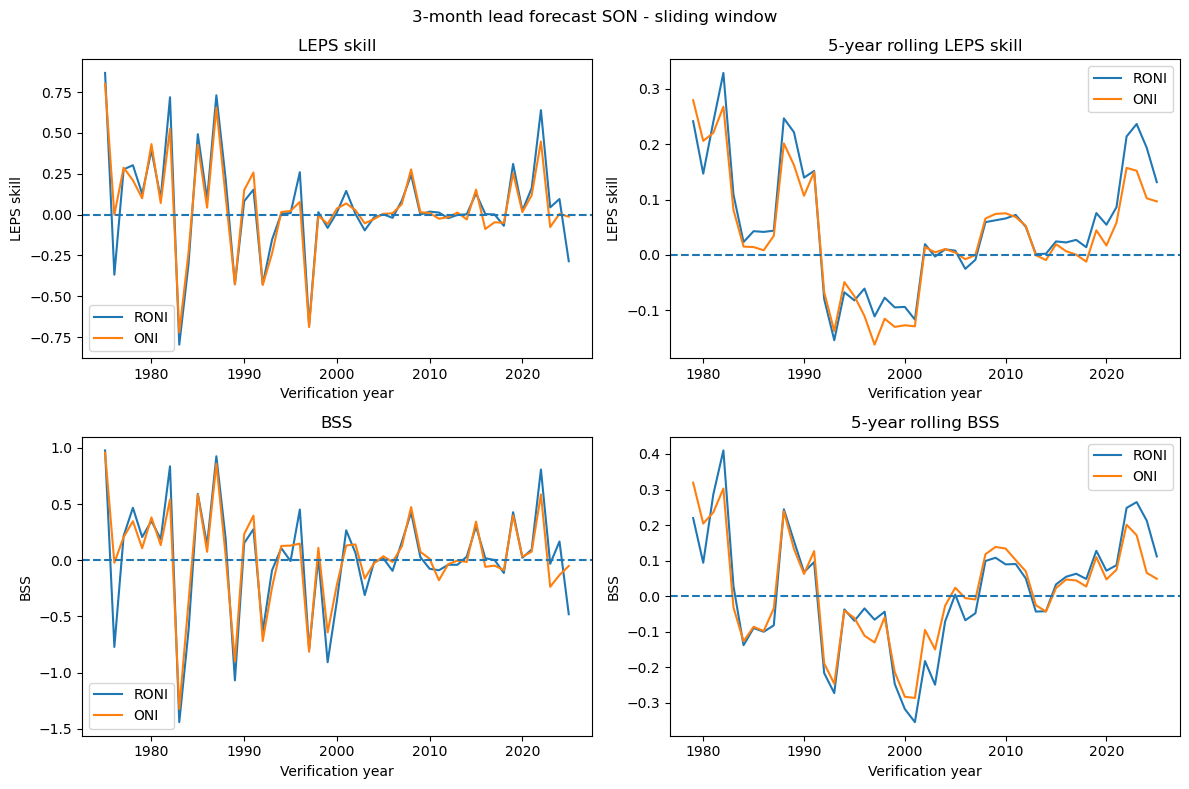

Mean RONI LEPS: 0.059815528196040066
Mean ONI LEPS: 0.048690855837001855
Mean RONI BSS: 0.01893956113525782
Mean ONI BSS: 0.030005808327467146


In [37]:
# Extract results from each iteration
years_ver = []
leps_roni = []
leps_oni = []
bss_roni = []
bss_oni = []

for score in scores:
    years_ver.append(score['years_verification'][0])

    leps_roni.append(score['roni']['LEPS skill'])
    leps_oni.append(score['oni']['LEPS skill'])

    bss_roni.append(score['roni']['BSS'])
    bss_oni.append(score['oni']['BSS'])


leps_roni_rolling = pd.Series(leps_roni).rolling(5).mean()
leps_oni_rolling = pd.Series(leps_oni).rolling(5).mean()

bss_roni_rolling = pd.Series(bss_roni).rolling(5).mean()
bss_oni_rolling = pd.Series(bss_oni).rolling(5).mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. LEPS by year
axes[0, 0].plot(years_ver, leps_roni, label='RONI')
axes[0, 0].plot(years_ver, leps_oni, label='ONI')
axes[0, 0].axhline(0, linestyle='--')
axes[0, 0].set_title('LEPS skill')
axes[0, 0].set_xlabel('Verification year')
axes[0, 0].set_ylabel('LEPS skill')
axes[0, 0].legend()

# 2. 5-year rolling LEPS
axes[0, 1].plot(years_ver, leps_roni_rolling, label='RONI')
axes[0, 1].plot(years_ver, leps_oni_rolling, label='ONI')
axes[0, 1].axhline(0, linestyle='--')
axes[0, 1].set_title('5-year rolling LEPS skill')
axes[0, 1].set_xlabel('Verification year')
axes[0, 1].set_ylabel('LEPS skill')
axes[0, 1].legend()

# 3. BSS by year
axes[1, 0].plot(years_ver, bss_roni, label='RONI')
axes[1, 0].plot(years_ver, bss_oni, label='ONI')
axes[1, 0].axhline(0, linestyle='--')
axes[1, 0].set_title('BSS')
axes[1, 0].set_xlabel('Verification year')
axes[1, 0].set_ylabel('BSS')
axes[1, 0].legend()

# 4. 5-year rolling BSS
axes[1, 1].plot(years_ver, bss_roni_rolling, label='RONI')
axes[1, 1].plot(years_ver, bss_oni_rolling, label='ONI')
axes[1, 1].axhline(0, linestyle='--')
axes[1, 1].set_title('5-year rolling BSS')
axes[1, 1].set_xlabel('Verification year')
axes[1, 1].set_ylabel('BSS')
axes[1, 1].legend()


fig.suptitle('3-month lead forecast SON - sliding window') 
plt.tight_layout()
plt.show()




print('Mean RONI LEPS:', np.mean(leps_roni))
print('Mean ONI LEPS:', np.mean(leps_oni))

print('Mean RONI BSS:', np.mean(bss_roni))
print('Mean ONI BSS:', np.mean(bss_oni))

In [35]:
# plotting (oni, roni, 1month lead, 3month lead, LEPS,BSS,HnM? for training methods) 